Queste sono le librerie che bisogna aver istallato per far girare il codice, chiedete a Chat come istallarle.

Non dovrebbe essere complicato ma io non mi ricordo.

Sotto ci sono delle celle con tutte le funzioni, vi sconsiglio di guardarle perchè sono incomprensibili ma tanto non vi serve modificarle penso.

In [57]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import minimize
from scipy import odr
from matplotlib import rcParams
from IPython.display import display, HTML

In [58]:
# Funzione Lettura File ".csv" in Dizionario
def csv_to_dict(csv: str) -> dict:
    df = pd.read_csv(csv)
    dizionario = {col: np.array(df[col]) for col in df.columns}
    return dizionario

# Fit Non Lineare con Minimizzazione del Chi Quadro o con Modello ODR
def fit(xdata, ydata, modello, beta0, chi=True):
    # Il parametro "chi" fa il fit minimizzando il chi quadro, altrimenti viene fatto con ODR
    # Nel modello definire prima par e poi x
    # Il risultato della funzione è una matrice che ha in ogni riga il valore del parametro e la sua incertezza, l'ordine è quello definito nel modello
    x, sx = xdata
    y, sy = ydata

    def chi2(par, x, y, sy):
        return np.sum(((y - modello(par,x)) / sy) ** 2)

    if chi:
        res = minimize(chi2, beta0, args=(x, y, sy))
        anal_chi = [
            [res.x[i], np.sqrt(abs(res.hess_inv[i][i]))]
            for i in range(len(res.x))
        ]
        return np.array(anal_chi)

    model = odr.Model(modello)
    data_odr = odr.RealData(x, y, sx=sx, sy=sy)
    odr_instance = odr.ODR(data_odr, model, beta0=beta0)
    res = odr_instance.run()

    anal_odr = [
        [res.beta[i], res.sd_beta[i]]
        for i in range(len(res.beta))
    ]
    return np.array(anal_odr)

# Funzione per la Creazione di un File di Output Vuoto
def inizializza_output (output_filename, latex=False):
    with open(output_filename, "w") as file:
        file.write('')
    if latex == True:
        latex_filename = output_filename.replace('.txt', '.tex')
        with open(latex_filename, 'w') as latex_file:
            latex_file.write('')

# Funzione per Salvare i Risultati dell'Analisi in un File di Testo
def salva_analisi(anal, parametri, nome_file):
    with open(nome_file, "w") as f:
        for i, nome in enumerate(parametri):
            valore = anal[i, 0]
            errore = anal[i, 1]
            
            # formato con 3 cifre significative
            riga = f"{nome} = {formatta_errore(valore,errore,txt=True)}\n"
            f.write(riga)

def residui(xdata,ydata,par,modello,file,titolo,n=8,f=2):
    # n decide la spaziatura tra i valori
    # f decide le cifre significative
    somma = 0.
    residui = []

    vx, vsx = xdata
    vy, vsy = ydata
    with open(file, 'a') as output_elab:
        output_elab.write(f"Test residui {titolo}_____________________________________________\n")
        output_elab.write(f"{'':<3}{'x':<{n}}{'y':<{n}}{'y*':<{n}}{'res':<{n}}{'s_res':<{n}}\n")
        for i, (x, y) in enumerate(zip(vx, vy)):
            y_star = modello(par, x)
            res = y - y_star
            s_res = vsy[i]  # banalmente uguale a sy

            somma += abs(res)
            residui.append([x, res, s_res])

            output_elab.write(
                f"{i+1:<3}{x:<{n}.{f}f}{y:<{n}.{f}f}{y_star:<{n}.{f}f}"
                f"{res:<{n}.{f}f}{s_res:<{n}.{f}f}\n"
            )
        output_elab.write(f"\nSomma residui = {somma:.{f}f}\n")
    residui = np.array(residui)
    res = np.array([residui[:,0], residui[:,1], residui[:,2]])
    return res

# Test del Chi Quadro
def chi_quadro(xdata,ydata,par,modello,file,titolo,n=8,f=2):
    # n decide la spaziatura tra i valori
    # f decide le cifre significative
    somma = 0.
    chi_quadri = []

    vx, vsx = xdata
    vy, vsy = ydata
    with open(file, 'a') as output_elab:
        output_elab.write(f"Test Chi Quadro {titolo}_____________________________________________\n")
        output_elab.write(f"{'':<3}{'x':<{n}}{'y':<{n}}{'y*':<{n}}{'sy':<{n}}{'Chi':<{n}}\n")
        for i,(x,y) in enumerate(zip(vx,vy)):
            y_star = modello(par,x)
            chi = ((y-y_star)/vsy[i])**2
            s_chi = vsy[i]

            somma += chi
            chi_quadri.append([x, chi, s_chi])

            output_elab.write(f"{i+1:<3}{x:<{n}.{f}f}{y:<{n}.{f}f}{y_star:<{n}.{f}f}{vsy[i]:<{n}.{f}f}{chi:<{n}.{f}f}\n")
        output_elab.write(f"Chi Quadro = {somma:.{f}f}\n")
        if np.isscalar(par):
                gradi = len(vy) - 1
        else:
            gradi = len(vy) - len(par)
        output_elab.write(f"Gradi Libertà = {gradi}\n")
        output_elab.write(f"Chi Quadro Ridotto = {somma/gradi:.{f}f}\n\n")
    chi_quadri = np.array(chi_quadri)
    chi = np.array([chi_quadri[:,0], chi_quadri[:,1], chi_quadri[:,2]])
    return chi

def parametri_grafico(ax, titolo=None, xlabel=None, ylabel=None, zlabel=None, tridimensionale=False):

    if tridimensionale:
        if titolo: ax.set_title(titolo, pad=20)
        if xlabel: ax.set_xlabel(xlabel, labelpad=10)
        if ylabel: ax.set_ylabel(ylabel, labelpad=10)
        if zlabel: ax.set_zlabel(zlabel, labelpad=10)
        ax.tick_params(axis='both', labelsize=16)
        ax.tick_params(axis='z', labelsize=16)
    else:
        if titolo: ax.set_title(titolo, pad=15)
        if xlabel: ax.set_xlabel(xlabel, labelpad=10)
        if ylabel: ax.set_ylabel(ylabel, labelpad=10)

    ax.tick_params(axis='both', labelsize=16)

# Salva e mostra l'immagine
def salva_grafico(fig, nomefile, formato='pdf', show=True):
    fig.tight_layout()

    fig.savefig(nomefile, bbox_inches='tight', format=formato, dpi=600)

    if show:
        plt.show()

In [59]:
# Funzione chiamata automaticamente in ogni file con "moduli.py"
def imposta_stile_globale():
    rcParams.update({
        # Figure
        "figure.figsize": (8, 6),
        "figure.dpi": 200,

        # Titoli e testo
        "axes.titlesize": 20,
        "axes.labelsize": 18, # Dimensione etichette assi
        "legend.fontsize": 16,
        "font.family": "serif",

        # Linee e marker
        "lines.linewidth": 2,
        "lines.markersize": 6,

        # Griglia
        "axes.grid": True,
        "grid.linestyle": "--",
        "grid.color": "gray",
        "grid.linewidth": 0.5,
        "grid.alpha": 0.7,
    })

# Parametri standard per errorbar
errorbar_params = {
        'elinewidth': 0.5,
        'capsize': 5,
        'capthick': 1,
        'fmt': '.',
    }

# Parametri standard per scatter
scatter_params ={
        's': 20,          # dimensione marker
        'marker': 'o',
        'alpha': 0.8,
    }

# Parametri standard per plot
plot_params = {
        'linewidth': 1.5,
        'linestyle': '-',
    }

# Parametri per axhline e axvline
line_params = {
        'linewidth': 1.0,
        'linestyle': '--',
        'alpha': 0.7
    }
line_params_ = {
        'linewidth': 1.0,
        'linestyle': '-',
        'alpha': 0.7
    }

# Ciclo di 10 colori
colori = [
        (0.121, 0.466, 0.705),  # blu
        (1.000, 0.498, 0.054),  # arancione
        (0.172, 0.627, 0.172),  # verde
        (0.839, 0.153, 0.157),  # rosso
        (0.580, 0.404, 0.741),  # viola
        (0.549, 0.337, 0.294),  # marrone
        (0.890, 0.467, 0.761),  # rosa
        (0.498, 0.498, 0.498),  # grigio
        (0.737, 0.741, 0.133),  # giallo-verde
        (0.090, 0.745, 0.811),  # ciano
    ]

# Visualizzazione di un dizionario in Jupyter in tabella HTML
def display_dizionario(d):
    html = dict_to_html_table(d)
    display(HTML(html))

def dict_to_html_table(d, depth=0):
    html = ''
    indent = '&nbsp;' * 4 * depth
    if isinstance(d, dict):
        html += '<table border="1" style="border-collapse: collapse;">'
        for key, value in d.items():
            html += '<tr>'
            html += f'<td>{indent}<strong>{key}</strong></td>'
            if isinstance(value, dict):
                html += f'<td>{dict_to_html_table(value, depth + 1)}</td>'
            else:
                html += f'<td>{indent}{value}</td>'
            html += '</tr>'
        html += '</table>'
    else:
        html += f'{indent}{d}'
    return html

# Formattazione di un valore con incertezza alle giuste cifre significative
def formatta_errore(val, err, unit='', html=False, txt=False):
    if err < 0:
        raise ValueError("Errore negativo no grazie.")

    # caso errore zero
    if np.isclose(err, 0):
        val_rounded = round(val, 3)
        if html:
            return f"{val_rounded:.3f} &plusmn; 0 {unit}"
        return rf"${val_rounded:.3f} \pm 0$ {unit}"

    # arrotonda errore a 1 cifra significativa
    err_round = arrotonda_significative(err, cifre=1)

    # ordine di grandezza errore
    exp_err = int(np.floor(np.log10(err_round)))
    dec = max(0, -exp_err)

    # 👉 SE TROPPI DECIMALI → SCIENTIFICA
    if dec > 3:
        exp = int(np.floor(np.log10(abs(val)))) if val != 0 else exp_err

        val_sci = val / 10**exp
        err_sci = err / 10**exp

        err_sci = arrotonda_significative(err_sci, cifre=1)

        # numero di decimali per mantissa
        exp_err_sci = int(np.floor(np.log10(err_sci)))
        dec_sci = max(0, -exp_err_sci)

        if html:
            return f"({val_sci:.{dec_sci}f} &plusmn; {err_sci:.{dec_sci}f}) × 10<sup>{exp}</sup> {unit}"
        if txt:
            return f"({val_sci:.{dec_sci}f} ± {err_sci:.{dec_sci}f}) × 10^{exp} {unit}"
        return rf"$({val_sci:.{dec_sci}f} \pm {err_sci:.{dec_sci}f}) \times 10^{{{exp}}}$ {unit}"

    # 👉 CASO NORMALE
    val_round = round(val, dec)

    if html:
        return f"{val_round:.{dec}f} &plusmn; {err_round:.{dec}f} {unit}"
    if txt:
        return f"{val_round:.{dec}f} ± {err_round:.{dec}f} {unit}"
    return rf"${val_round:.{dec}f} \pm {err_round:.{dec}f}$ {unit}"

def arrotonda_significative(x, cifre=2):
    if x == 0:
        return 0.0
    exp = int(np.floor(np.log10(abs(x))))
    fattore = 10**(cifre - 1 - exp)
    return round(x * fattore) / fattore

In [60]:
imposta_stile_globale()

Questi sono i titoli dei vari file che vengono creati, non è strettamente necessario modificarli ma se volete potete.

In [61]:
titolo = "Esperienza"
xlabel = "x"
ylabel = "y"

file_input = "dati.csv" #Nome del file di input dei dati, deve essere un csv del tipo "x,sx,y,sy"
file_output1 = "regressione.txt"
file_output2 = "residui.txt"
file_output3 = "chi.txt"
grafico_output1 = "regressione.pdf"
grafico_output2 = "residui.pdf"
grafico_output3 = "chi.pdf"

### 1. Lettura

In [62]:
data = csv_to_dict(file_input)

### 2. Analisi

Regressione

In [63]:
xdata = np.array([data["x"],data["sx"]])
ydata = np.array([data["y"],data["sy"]])

# Questo è il modello lineare per la regressione, se volete potete modificarlo per fare un fit su un modello diverso, basta che sia una funzione che prende in input i parametri e x e restituisce y
def modello(par, x):
    a,b = par
    return a + b*x

# Questa è la lista dei nomi dei parametri, verranno visualizzati poi nel grafico, devono essere in ordine corrispondente a quello dei parametri nel modello
param_labels = ['a','b']

anal = fit(xdata,ydata,modello,[0,1])

inizializza_output(file_output1)
salva_analisi(anal, param_labels, file_output1)

Residui

In [64]:
inizializza_output(file_output2)
res = residui(xdata,ydata,anal[:,0],modello,file_output2,titolo)

Chi Quadro

In [65]:
inizializza_output(file_output3)
chi = chi_quadro(xdata,ydata,anal[:,0],modello,file_output3,titolo)

### 3. Grafici

Regressione

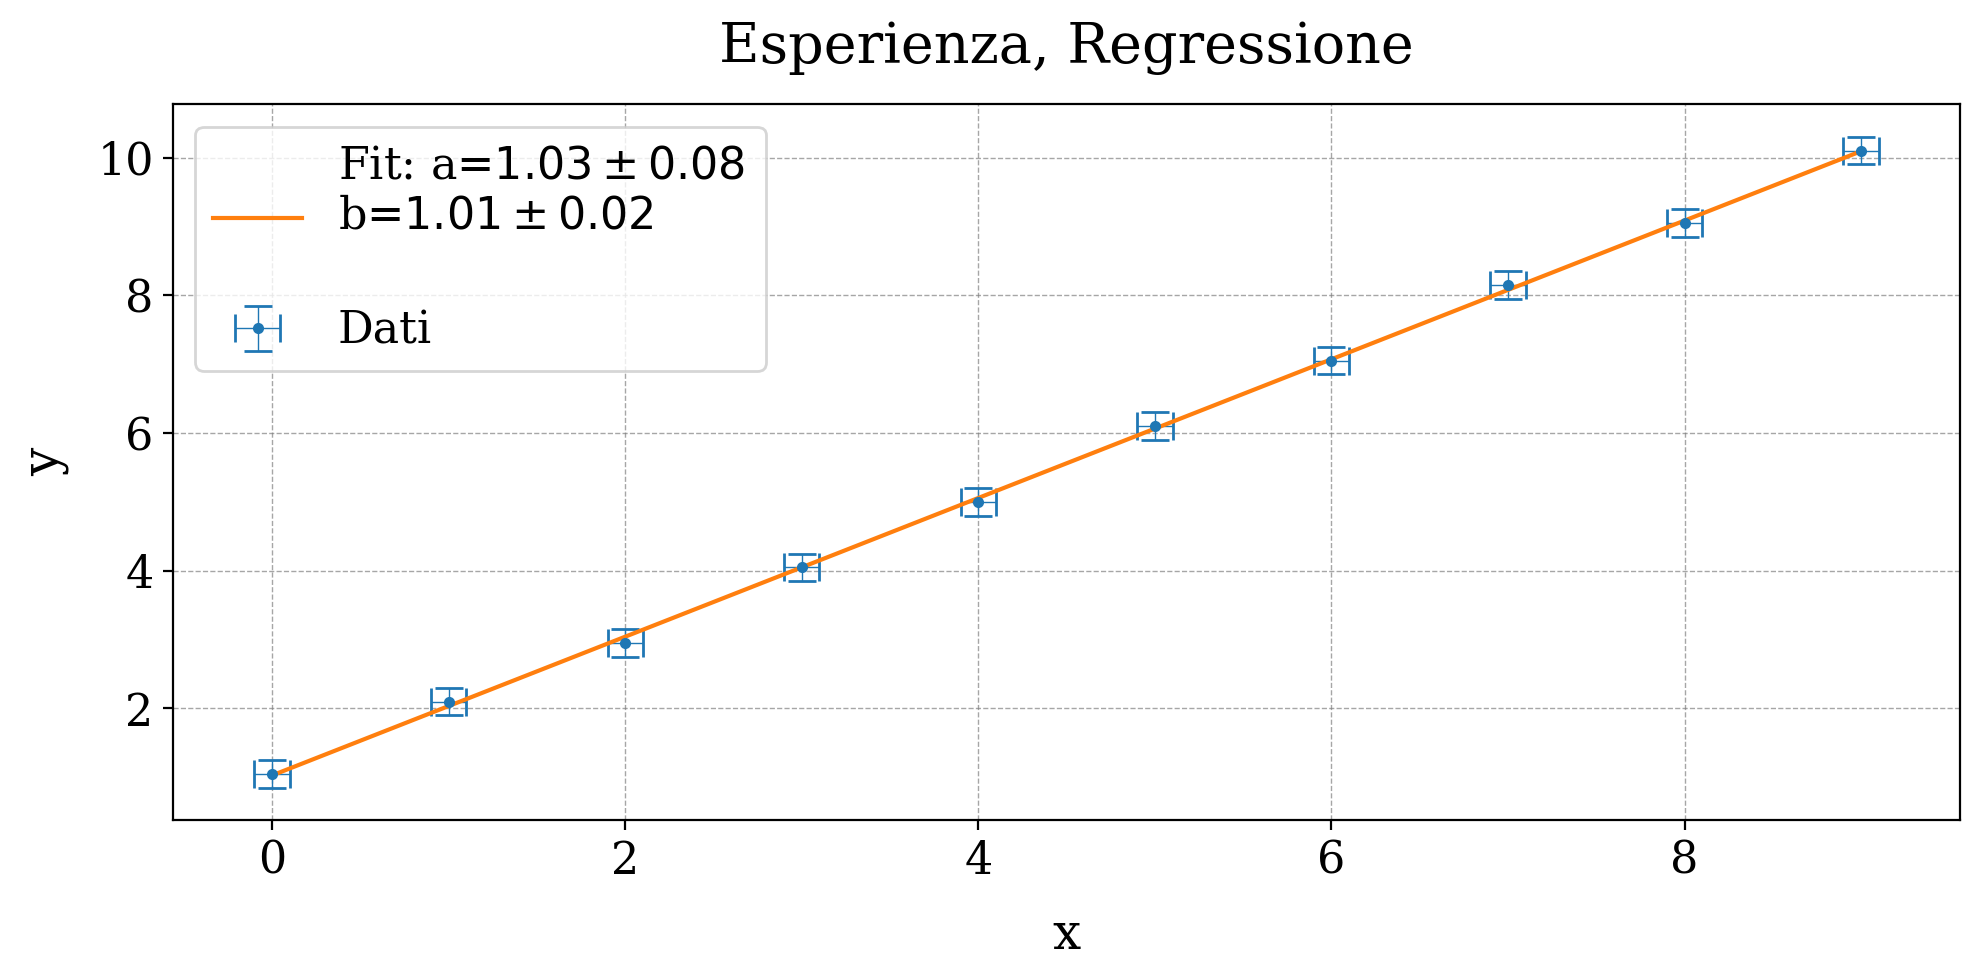

In [66]:
fig,ax = plt.subplots(1, 1,  figsize=(10, 5))
parametri_grafico(ax,titolo + ", Regressione",xlabel=xlabel,ylabel=ylabel)
# Grafico dei dati con errori
ax.errorbar(xdata[0],ydata[0],xerr=xdata[1],yerr=ydata[1],
            label="Dati", **errorbar_params, color = colori[0])
# Grafico del fit
fit_label = "Fit: " + "".join(
    f"{param_labels[i]}={formatta_errore(anal[i,0],anal[i,1])}\n" for i in range(len(param_labels))
)
x_fit = np.linspace(min(xdata[0]), max(xdata[0]), 500)
ax.plot(x_fit,modello(anal[:,0],x_fit),
        label=fit_label, **plot_params, color = colori[1])

ax.legend()

salva_grafico(fig,grafico_output1)

Residui

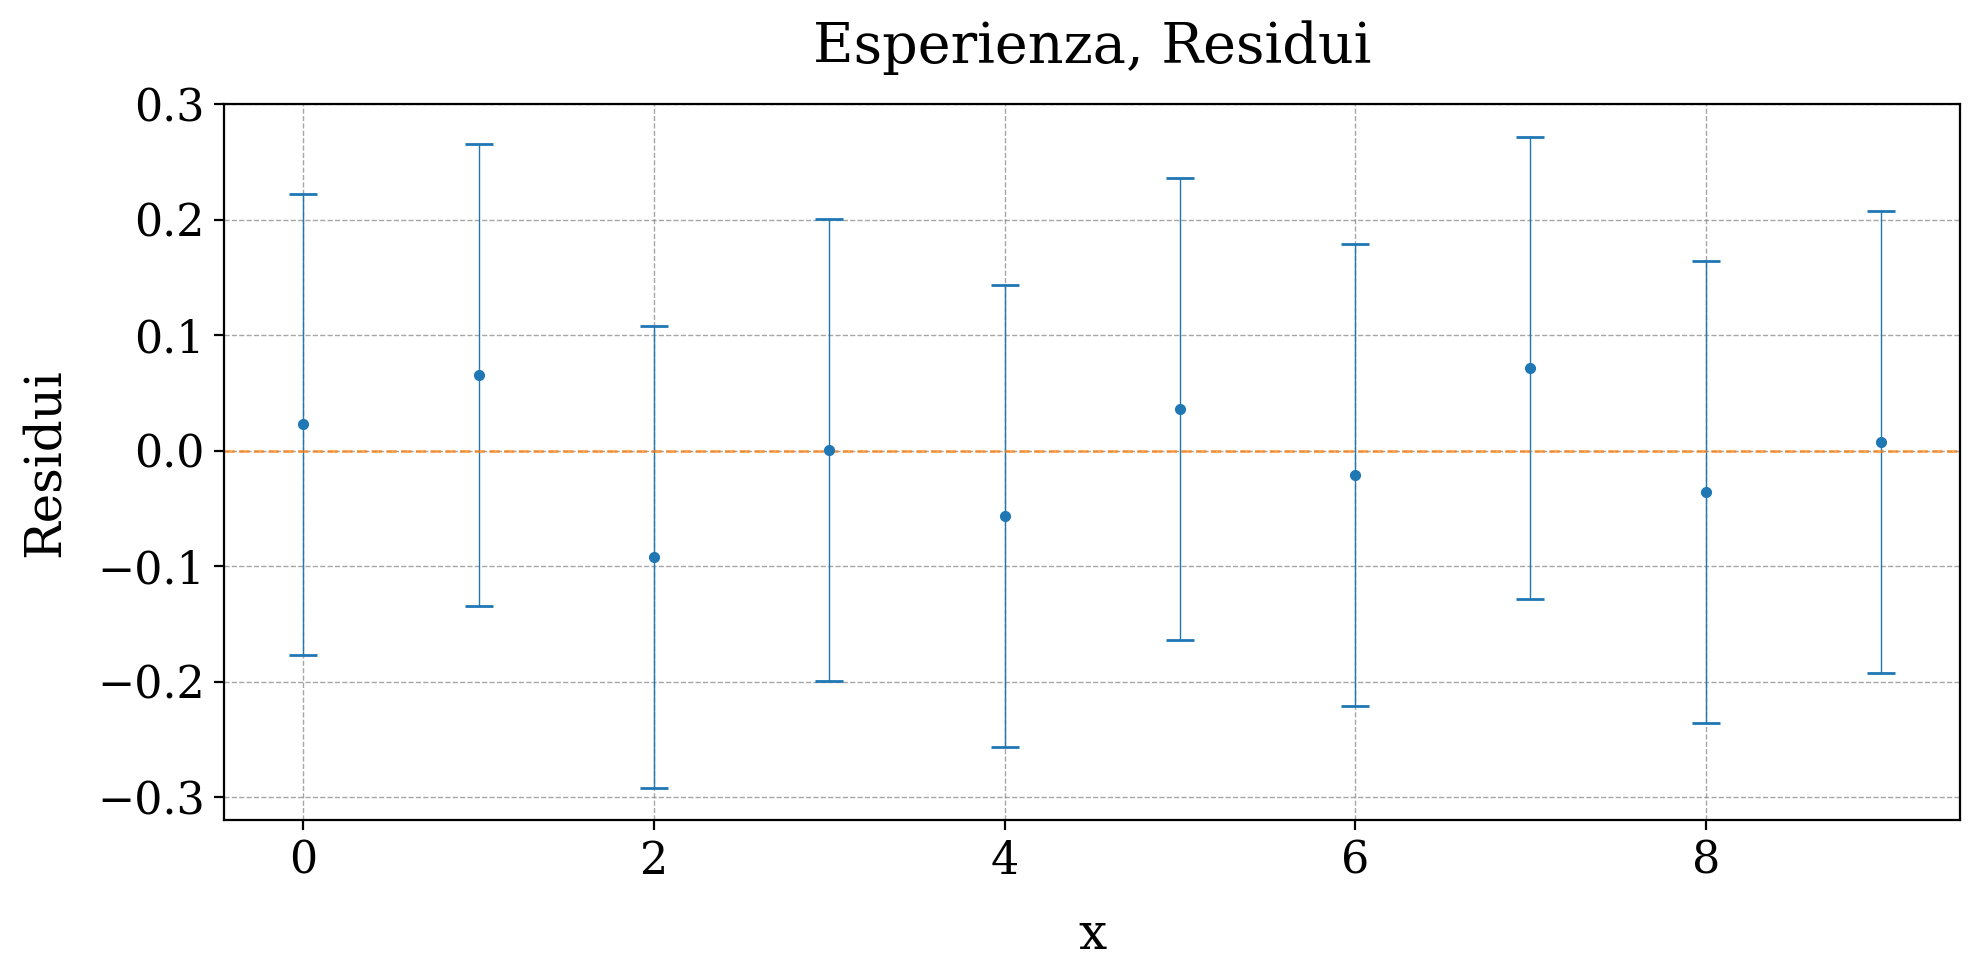

In [67]:
fig,ax = plt.subplots(1, 1,  figsize=(10, 5))
parametri_grafico(ax,titolo + ", Residui",xlabel=xlabel,ylabel="Residui")

ax.errorbar(res[0],res[1],yerr=res[2],
            **errorbar_params, color=colori[0])
ax.axhline(0,
           **line_params, color=colori[1])

salva_grafico(fig,grafico_output2)

Chi Quadro

<>:2: SyntaxWarning: invalid escape sequence '\c'
<>:2: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_4807/2811158867.py:2: SyntaxWarning: invalid escape sequence '\c'
  parametri_grafico(ax,titolo + r", $\chi^2$",xlabel=xlabel,ylabel="$\chi^2$")


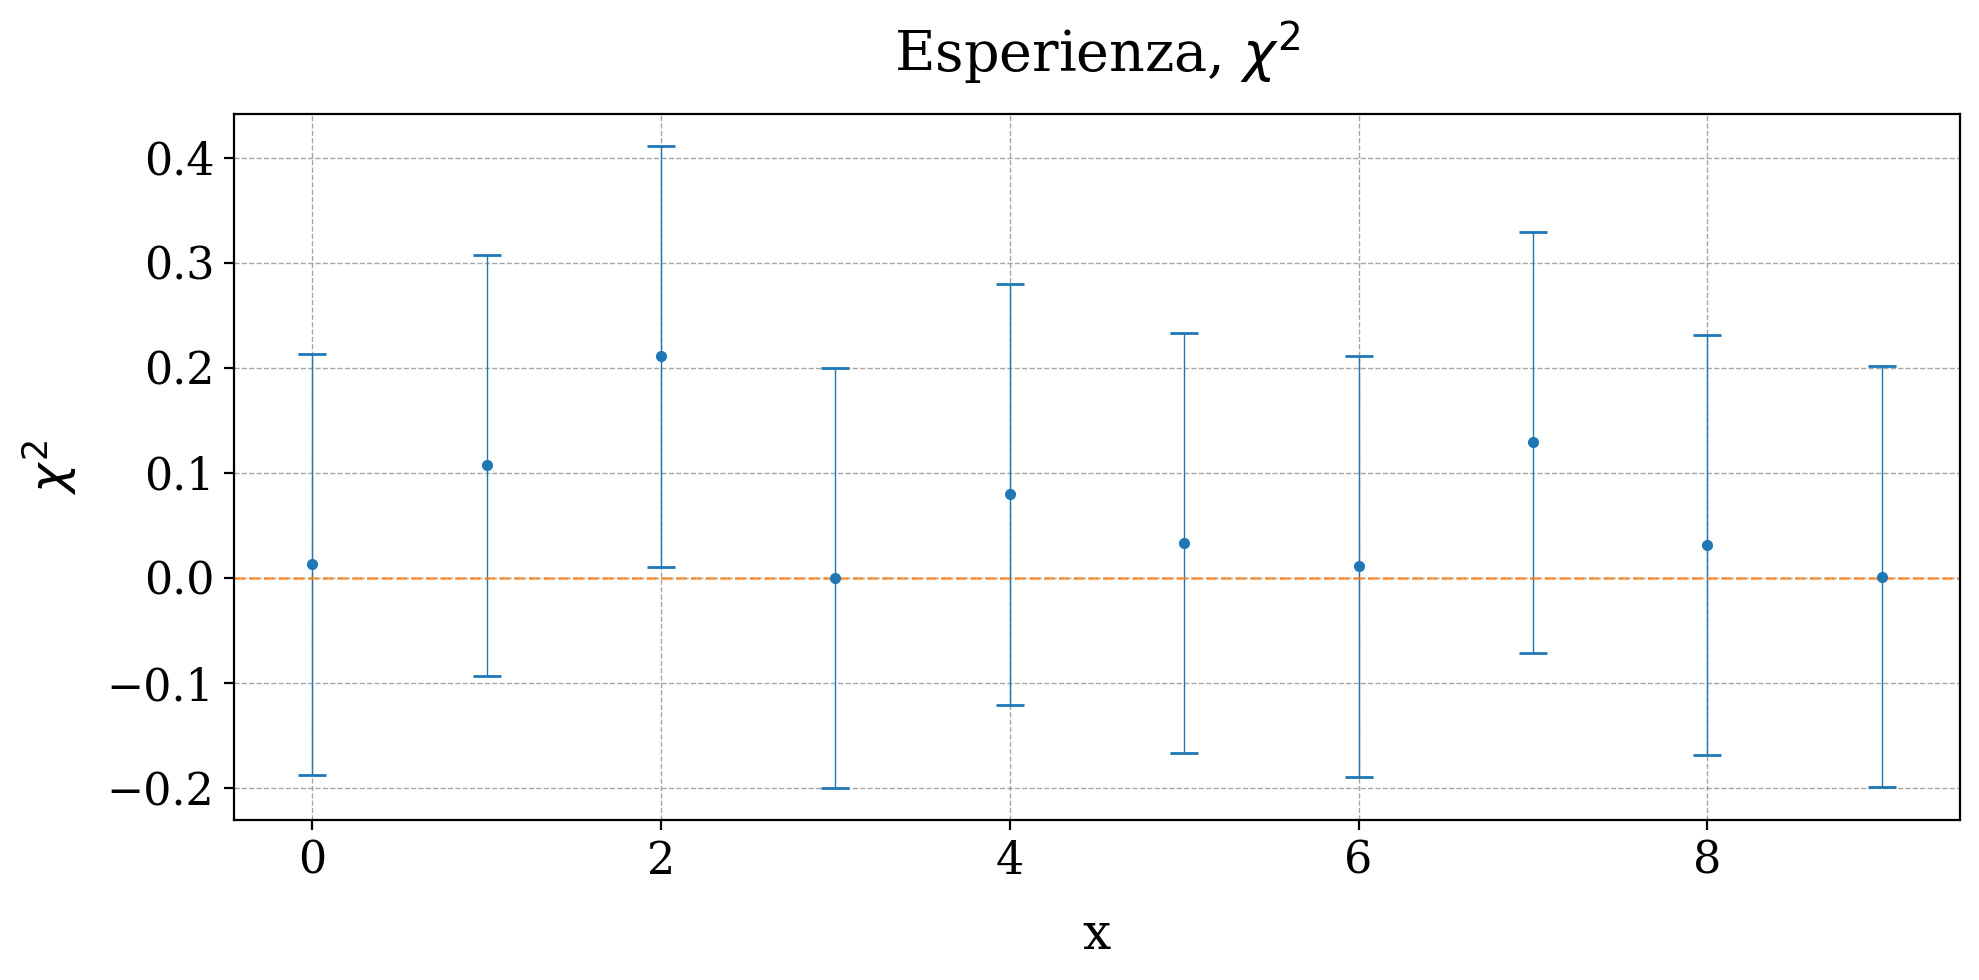

In [68]:
fig,ax = plt.subplots(1, 1,  figsize=(10, 5))
parametri_grafico(ax,titolo + r", $\chi^2$",xlabel=xlabel,ylabel="$\chi^2$")

ax.errorbar(chi[0],chi[1],yerr=chi[2],
            **errorbar_params, color=colori[0])
ax.axhline(0,
           **line_params, color=colori[1])

salva_grafico(fig,grafico_output3)